In [1]:
import gpytorch
import torch

from helpers.gp_classes import DataGPModel, ExactGPModel
from helpers.plotting_functions import plot_training_data, plot_single_input_gp_posterior
from helpers.training_functions import granso_optimization
from helpers.util_functions import prior_distribution, extract_model_parameters, reparameterize_model

import matplotlib.pyplot as plt

In [2]:

import numpy as np
import torch

def nearest_idx_torch(a, b):
    a = torch.as_tensor(a)
    b = torch.as_tensor(b)
    # pairwise distances for 1D values
    idx = (a[:, None] - b[None, :]).abs().argmin(dim=1)
    all_idx = torch.arange(b.shape[0], device=b.device)
    remaining_b = b[~torch.isin(all_idx, idx)]
    return idx, ~torch.isin(all_idx, idx), b[idx], remaining_b


def generate_appended_prediction_data(data_model, data_likelihood, train_obs, all_observations_y, eval_obs, test_dataset_count=10):
    total_obs = torch.cat([train_obs, eval_obs], dim=0)

    # Store if model is in training mode
    previous_state = data_model.training

    # Get into evaluation (predictive posterior) mode
    data_model.eval()
    data_likelihood.eval()

    all_test_observations_y = []
    for i in range(len(all_observations_y)):
        data_model.set_train_data(train_obs, all_observations_y[i], strict=False)
        with torch.no_grad():
            #f_preds = data_likelihood(data_model(eval_obs))
            f_preds = data_model(eval_obs)
        test_observations_y = f_preds.sample_n(test_dataset_count)
        all_test_observations_y.append(test_observations_y)

    # Reverse to previous state
    if previous_state:
        data_model.train()
        data_likelihood.train()

    return eval_obs, all_test_observations_y


def sample_data_from_gp(train_START, train_END, train_COUNT, data_kernel, eval_START=None, eval_END=None, eval_COUNT=100, train_dataset_count=5, test_data=True, test_dataset_count=10, interleaved_to_appended_ratio=0.0, use_interleaved_data_as_train_for_app_eval=False):
    if test_data: 
        # I want test data, but the interleaved ratio is smaller than 1.0 and there is no eval_START and no eval_END
        if interleaved_to_appended_ratio < 1.0 and (eval_START is None or eval_END is None):
            raise ValueError("If you want appended test data, you need to provide eval_START and eval_END.")
        

    # training data for model initialization (e.g. 1 point with x=0, y=0) ; this makes initializing the model easier
    prior_x = torch.linspace(0, 1, 1)
    prior_y = prior_x

    # initialize likelihood and model
    data_likelihood = gpytorch.likelihoods.GaussianLikelihood()
    data_model = DataGPModel(prior_x, prior_y, data_likelihood, kernel_name=data_kernel)

    int_eval_COUNT = int(interleaved_to_appended_ratio * eval_COUNT)
    app_eval_COUNT = eval_COUNT - int_eval_COUNT

    # The interleaved data
    total_obs = torch.linspace(train_START, train_END, train_COUNT + int_eval_COUNT)
    train_obs = torch.linspace(train_START, train_END, train_COUNT)

    train_idx, int_eval_idx, train_obs, int_eval_obs = nearest_idx_torch(train_obs, total_obs)
    assert len(train_obs) == train_COUNT, "Something went wrong with the interleaved training data sampling."
    assert len(int_eval_obs) == int_eval_COUNT, "Something went wrong with the interleaved evaluation data sampling."
    assert len(int_eval_obs) + len(train_obs) == len(total_obs), "Something went wrong with the interleaved data sampling."

    # Get into evaluation (predictive posterior) mode
    data_model.eval()
    data_likelihood.eval()

    # Make predictions by feeding model
    with torch.no_grad(), gpytorch.settings.prior_mode(True):
        all_obs_preds = data_model(total_obs)

    all_observations_y = all_obs_preds.sample_n(max(train_dataset_count, test_dataset_count))
    all_int_eval_observations_y = all_observations_y[:, int_eval_idx]
    all_train_observations_y = all_observations_y[:, train_idx]

    if test_data is False:
        return (train_obs, all_train_observations_y), (None, None), (None, None)

    # The appended data
    if interleaved_to_appended_ratio == 1.0:
        return (train_obs, all_train_observations_y), (int_eval_obs, all_int_eval_observations_y), (None, None)
    eval_obs = torch.linspace(eval_START, eval_END, app_eval_COUNT)

    # Set the nosie to be almost zero to have the prediction samples continuously connected to the generated training data
    model_params = extract_model_parameters(data_model)
    model_params_bak = model_params.clone()
    model_params[0] = -10.0 # 
    reparameterize_model(data_model, model_params)

    # Use the interleaved data to further "constrain" the predictions for the appended test data
    if use_interleaved_data_as_train_for_app_eval:
        app_eval_obs, all_app_test_observations_y = generate_appended_prediction_data(data_model, data_likelihood, total_obs, all_observations_y=all_observations_y, eval_obs=eval_obs, test_dataset_count=test_dataset_count)
    # Or use only the training data
    else:
        app_eval_obs, all_app_test_observations_y = generate_appended_prediction_data(data_model, data_likelihood, train_obs, all_observations_y=all_train_observations_y, eval_obs=eval_obs, test_dataset_count=test_dataset_count)

    reparameterize_model(data_model, model_params_bak)


    if interleaved_to_appended_ratio == 0.0:
        return (train_obs, all_train_observations_y), (None, None), (app_eval_obs, all_app_test_observations_y)

    return (train_obs, all_train_observations_y), (int_eval_obs, all_int_eval_observations_y), (app_eval_obs, all_app_test_observations_y)

In [3]:
nearest_idx_torch(torch.linspace(0, 1, 15), torch.linspace(0, 1, 20))

(tensor([ 0,  1,  3,  4,  5,  7,  8,  9, 11, 12, 14, 15, 16, 18, 19]),
 tensor([False, False,  True, False, False, False,  True, False, False, False,
          True, False, False,  True, False, False, False,  True, False, False]),
 tensor([0.0000, 0.0526, 0.1579, 0.2105, 0.2632, 0.3684, 0.4211, 0.4737, 0.5789,
         0.6316, 0.7368, 0.7895, 0.8421, 0.9474, 1.0000]),
 tensor([0.1053, 0.3158, 0.5263, 0.6842, 0.8947]))

In [4]:
# test cases

# 1. Only train data
(train_pos, train_obs), (int_eval_pos, int_eval_obs), (eval_pos, eval_obs) = sample_data_from_gp(train_START=0, train_END=1, train_COUNT=50, data_kernel="SE", train_dataset_count=3, test_data=False)

# 2. Train + Test data in non-interleaved mode
(train_pos, train_obs), (int_eval_pos, int_eval_obs), (eval_pos, eval_obs) =  sample_data_from_gp(train_START=0, train_END=1, train_COUNT=50, eval_START=1, eval_END=2, eval_COUNT=200, data_kernel="SE", train_dataset_count=3, test_data=True, test_dataset_count=10)

# eval_obs has shape [train_dataset_count, test_dataset_count, eval_COUNT]

# 3. Train + Test data in interleaved mode
(train_pos, train_obs), (int_eval_pos, int_eval_obs), (eval_pos, eval_obs) =  sample_data_from_gp(train_START=0, train_END=1, train_COUNT=50, eval_COUNT=200, data_kernel="SE", train_dataset_count=3, test_data=True, test_dataset_count=10, interleaved_to_appended_ratio=1.0)

# 4. Train + Test data in interleaved and non-interleaved mode
(train_pos, train_obs), (int_eval_pos, int_eval_obs), (eval_pos, eval_obs) =  sample_data_from_gp(train_START=0, train_END=1, train_COUNT=50, eval_START=1, eval_END=2, eval_COUNT=100, data_kernel="SE", train_dataset_count=3, test_data=True, test_dataset_count=10, interleaved_to_appended_ratio=0.5)

# 5. Train + Test data in non-interleaved mode on the same range (This could just be done by creating more train datasets and simply using some of them for evaluation. Therefore this is unnecessary)
(train_pos, train_obs), (int_eval_pos, int_eval_obs), (eval_pos, eval_obs) =  sample_data_from_gp(train_START=0, train_END=1, train_COUNT=50, data_kernel="SE", test_data=False, train_dataset_count=10)
(train_pos, train_obs), (int_eval_pos, int_eval_obs), (eval_pos, eval_obs)

/home/andreas/anaconda3/envs/laplace/lib/python3.12/site-packages/torch/distributions/distribution.py:179: UserWarning: sample_n will be deprecated. Use .sample((n,)) instead
  warnings.warn(
/home/andreas/anaconda3/envs/laplace/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
/home/andreas/anaconda3/envs/laplace/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-05 to the diagonal
  warnings.warn(


((tensor([0.0000, 0.0204, 0.0408, 0.0612, 0.0816, 0.1020, 0.1224, 0.1429, 0.1633,
          0.1837, 0.2041, 0.2245, 0.2449, 0.2653, 0.2857, 0.3061, 0.3265, 0.3469,
          0.3673, 0.3878, 0.4082, 0.4286, 0.4490, 0.4694, 0.4898, 0.5102, 0.5306,
          0.5510, 0.5714, 0.5918, 0.6122, 0.6327, 0.6531, 0.6735, 0.6939, 0.7143,
          0.7347, 0.7551, 0.7755, 0.7959, 0.8163, 0.8367, 0.8571, 0.8776, 0.8980,
          0.9184, 0.9388, 0.9592, 0.9796, 1.0000]),
  tensor([[-3.9689e-01, -4.0655e-01, -4.1545e-01, -4.2735e-01, -4.3752e-01,
           -4.4775e-01, -4.5702e-01, -4.6648e-01, -4.7566e-01, -4.8382e-01,
           -4.9457e-01, -5.0322e-01, -5.1229e-01, -5.1942e-01, -5.2807e-01,
           -5.3724e-01, -5.4481e-01, -5.5436e-01, -5.6144e-01, -5.6926e-01,
           -5.7696e-01, -5.8358e-01, -5.9207e-01, -5.9730e-01, -6.0317e-01,
           -6.1057e-01, -6.1610e-01, -6.2055e-01, -6.2562e-01, -6.2825e-01,
           -6.3080e-01, -6.3157e-01, -6.3507e-01, -6.3385e-01, -6.3413e-01,
      

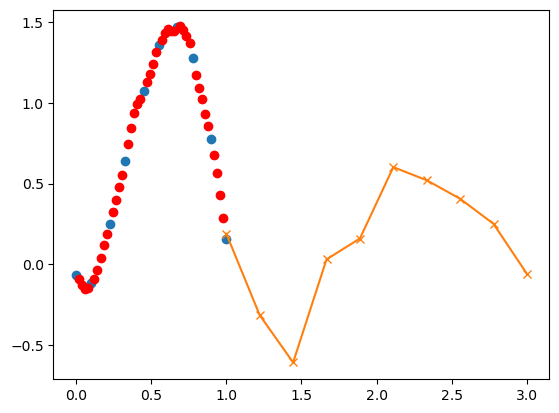

In [29]:
(train_pos, train_obs), (int_test_pos, int_test_obs), (eval_pos, eval_obs) = sample_data_from_gp(train_START=0, train_END=1, train_COUNT=10, eval_START=1, eval_END=3, eval_COUNT=50, data_kernel="MAT32", train_dataset_count=1, test_data=True, test_dataset_count=1, interleaved_to_appended_ratio=0.80, use_interleaved_data_as_train_for_app_eval=False)
plt.plot(train_pos, train_obs[0,:], 'o')
plt.plot(int_test_pos, int_test_obs[0,:], 'ro')
plt.plot(eval_pos, eval_obs[0][0], 'x-')

tensor(5.2433)
tensor([0., 0.], grad_fn=<CatBackward0>)
tensor(4.1542)


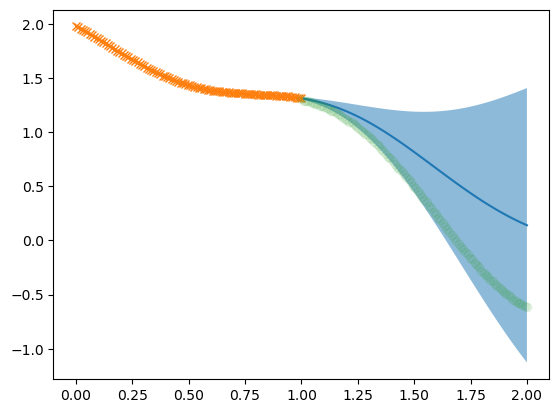

In [83]:
train_x = torch.linspace(0, 1, 1)
train_y = torch.linspace(0, 1, 1)
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = DataGPModel(train_x=train_x, train_y=train_y, likelihood=likelihood, kernel_name="SE")
model.eval()
likelihood.eval()
with torch.no_grad(), gpytorch.settings.prior_mode(True):
    f_preds = model(torch.linspace(0, 1, 100))
    sample = f_preds.sample()
    print(f_preds.log_prob(sample)/100)

model.set_train_data(torch.linspace(0, 1, 100), sample, strict=False)
print(extract_model_parameters(model))
model_params = extract_model_parameters(model)
model_params[0] = -10
reparameterize_model(model, model_params)
with torch.no_grad():
    f_preds = model(torch.linspace(1, 2, 100))
    pred_sample = f_preds.sample()
    print(f_preds.log_prob(pred_sample)/100)
    mean = f_preds.mean
    lower, upper = f_preds.confidence_region()
plt.plot(torch.linspace(1, 2, 100).numpy(), mean.numpy())
plt.fill_between(torch.linspace(1, 2, 100).numpy(), lower.numpy(), upper.numpy(), alpha=0.5)
plt.plot(torch.linspace(0, 1, 100).numpy(), sample.numpy(), 'x')
plt.plot(torch.linspace(1, 2, 100).numpy(), pred_sample.numpy(), 'o', alpha=0.1)
plt.show()